# Steam Games - Exploratory Data Analysis

**Project:** Steam Games Success Analysis  
**Author:** Edwin Chen

**Dataset:** [FronkonGames/steam-games-dataset](https://huggingface.co/datasets/FronkonGames/steam-games-dataset) · [andrewmvd/steam-reviews](https://www.kaggle.com/datasets/andrewmvd/steam-reviews)

---

## Overview

This notebook performs an exploratory data analysis (EDA) on a dataset of over 124,000 Steam games.  
The primary objective is to identify patterns and factors associated with game success on the platform, measured through **positive review rate**, **review volume**, and **estimated ownership**.

The analysis is structured into five sections:

1. **Base Distributions** - Understanding the shape of key variables
2. **Temporal Trends** - How the Steam catalog has evolved over time
3. **Genre Analysis** - Which genres dominate and which receive the best reception
4. **Correlations with Success** - Relationships between price, playtime, and user satisfaction
5. **Platform Support** - Impact of multi-platform availability on reach and ratings

> All data was previously cleaned in `data_cleaning.ipynb`. Processed files are loaded from `data/processed/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#To see all the columns for a better EDA
pd.set_option('display.max_columns', None) 
# Apply consistent visual 
sns.set_theme(style='darkgrid', palette='muted') 
# Default plot settigs
plt.rcParams.update({ 
    "figure.dpi" : 150,
    "axes.titlesize" : 13,
    "axes.labelsize" : 12,
    "axes.titleweight" : "bold",
})

In [2]:
games = pd.read_csv('../data/processed/games_clean.csv', dtype={'appid': str})

rev_agg = pd.read_csv('../data/processed/reviews_agg.csv', dtype={'app_id': str})

print(f'Games: {games.shape}')
print(f'Reviews agg: {rev_agg.shape}')

Games: (124146, 35)
Reviews agg: (332, 5)


In [3]:
games['total_reviews'] = games['positive'] + games['negative'] # get total reviews
games['positive_rate'] = np.where( # get the positive rate of games
    games['total_reviews'] > 0,    # where it has at least 1 reivew
    games['positive'] / games['total_reviews'], 
    np.nan
)

games_reviewed = games[games['total_reviews'] >= 10].copy()
print(f'Games with >= 10 reviews: {len(games_reviewed):,} / {len(games):,}')

print(f'\nPositive rate describe:')
print(games_reviewed['positive_rate'].describe())

print(f'\nTop 5 by positive:')
print(games_reviewed[['name','positive','negative','positive_rate']]
      .sort_values('positive', ascending=False).head())

Games with >= 10 reviews: 56,657 / 124,146

Positive rate describe:
count    56657.000000
mean         0.772230
std          0.178924
min          0.000000
25%          0.672727
50%          0.812500
75%          0.910180
max          1.000000
Name: positive_rate, dtype: float64

Top 5 by positive:
                            name  positive  negative  positive_rate
45509           Counter-Strike 2   7642084   1173003       0.866932
4193                      Dota 2   2037143    461826       0.815193
59122  Grand Theft Auto V Legacy   1739980    250576       0.874118
8878         PUBG: BATTLEGROUNDS   1520457   1037487       0.594406
10927                   Terraria   1373979     35494       0.974818


---
## **1. Base Distributions**

Before drawing any conclusions, it is essential to understand the underlying distribution of the most critical variables: **price**, **review volume**, and **user sentiment**.

This section addresses four foundational questions:
- How are game prices distributed across the catalog?
- What proportion of Steam games are Free to Play vs. paid?
- How skewed is the distribution of positive reviews?
- What does the overall user sentiment landscape look like?

These distributions set the baseline for all subsequent analyses and help identify the presence of skewness and outliers that must be accounted for in interpretation.

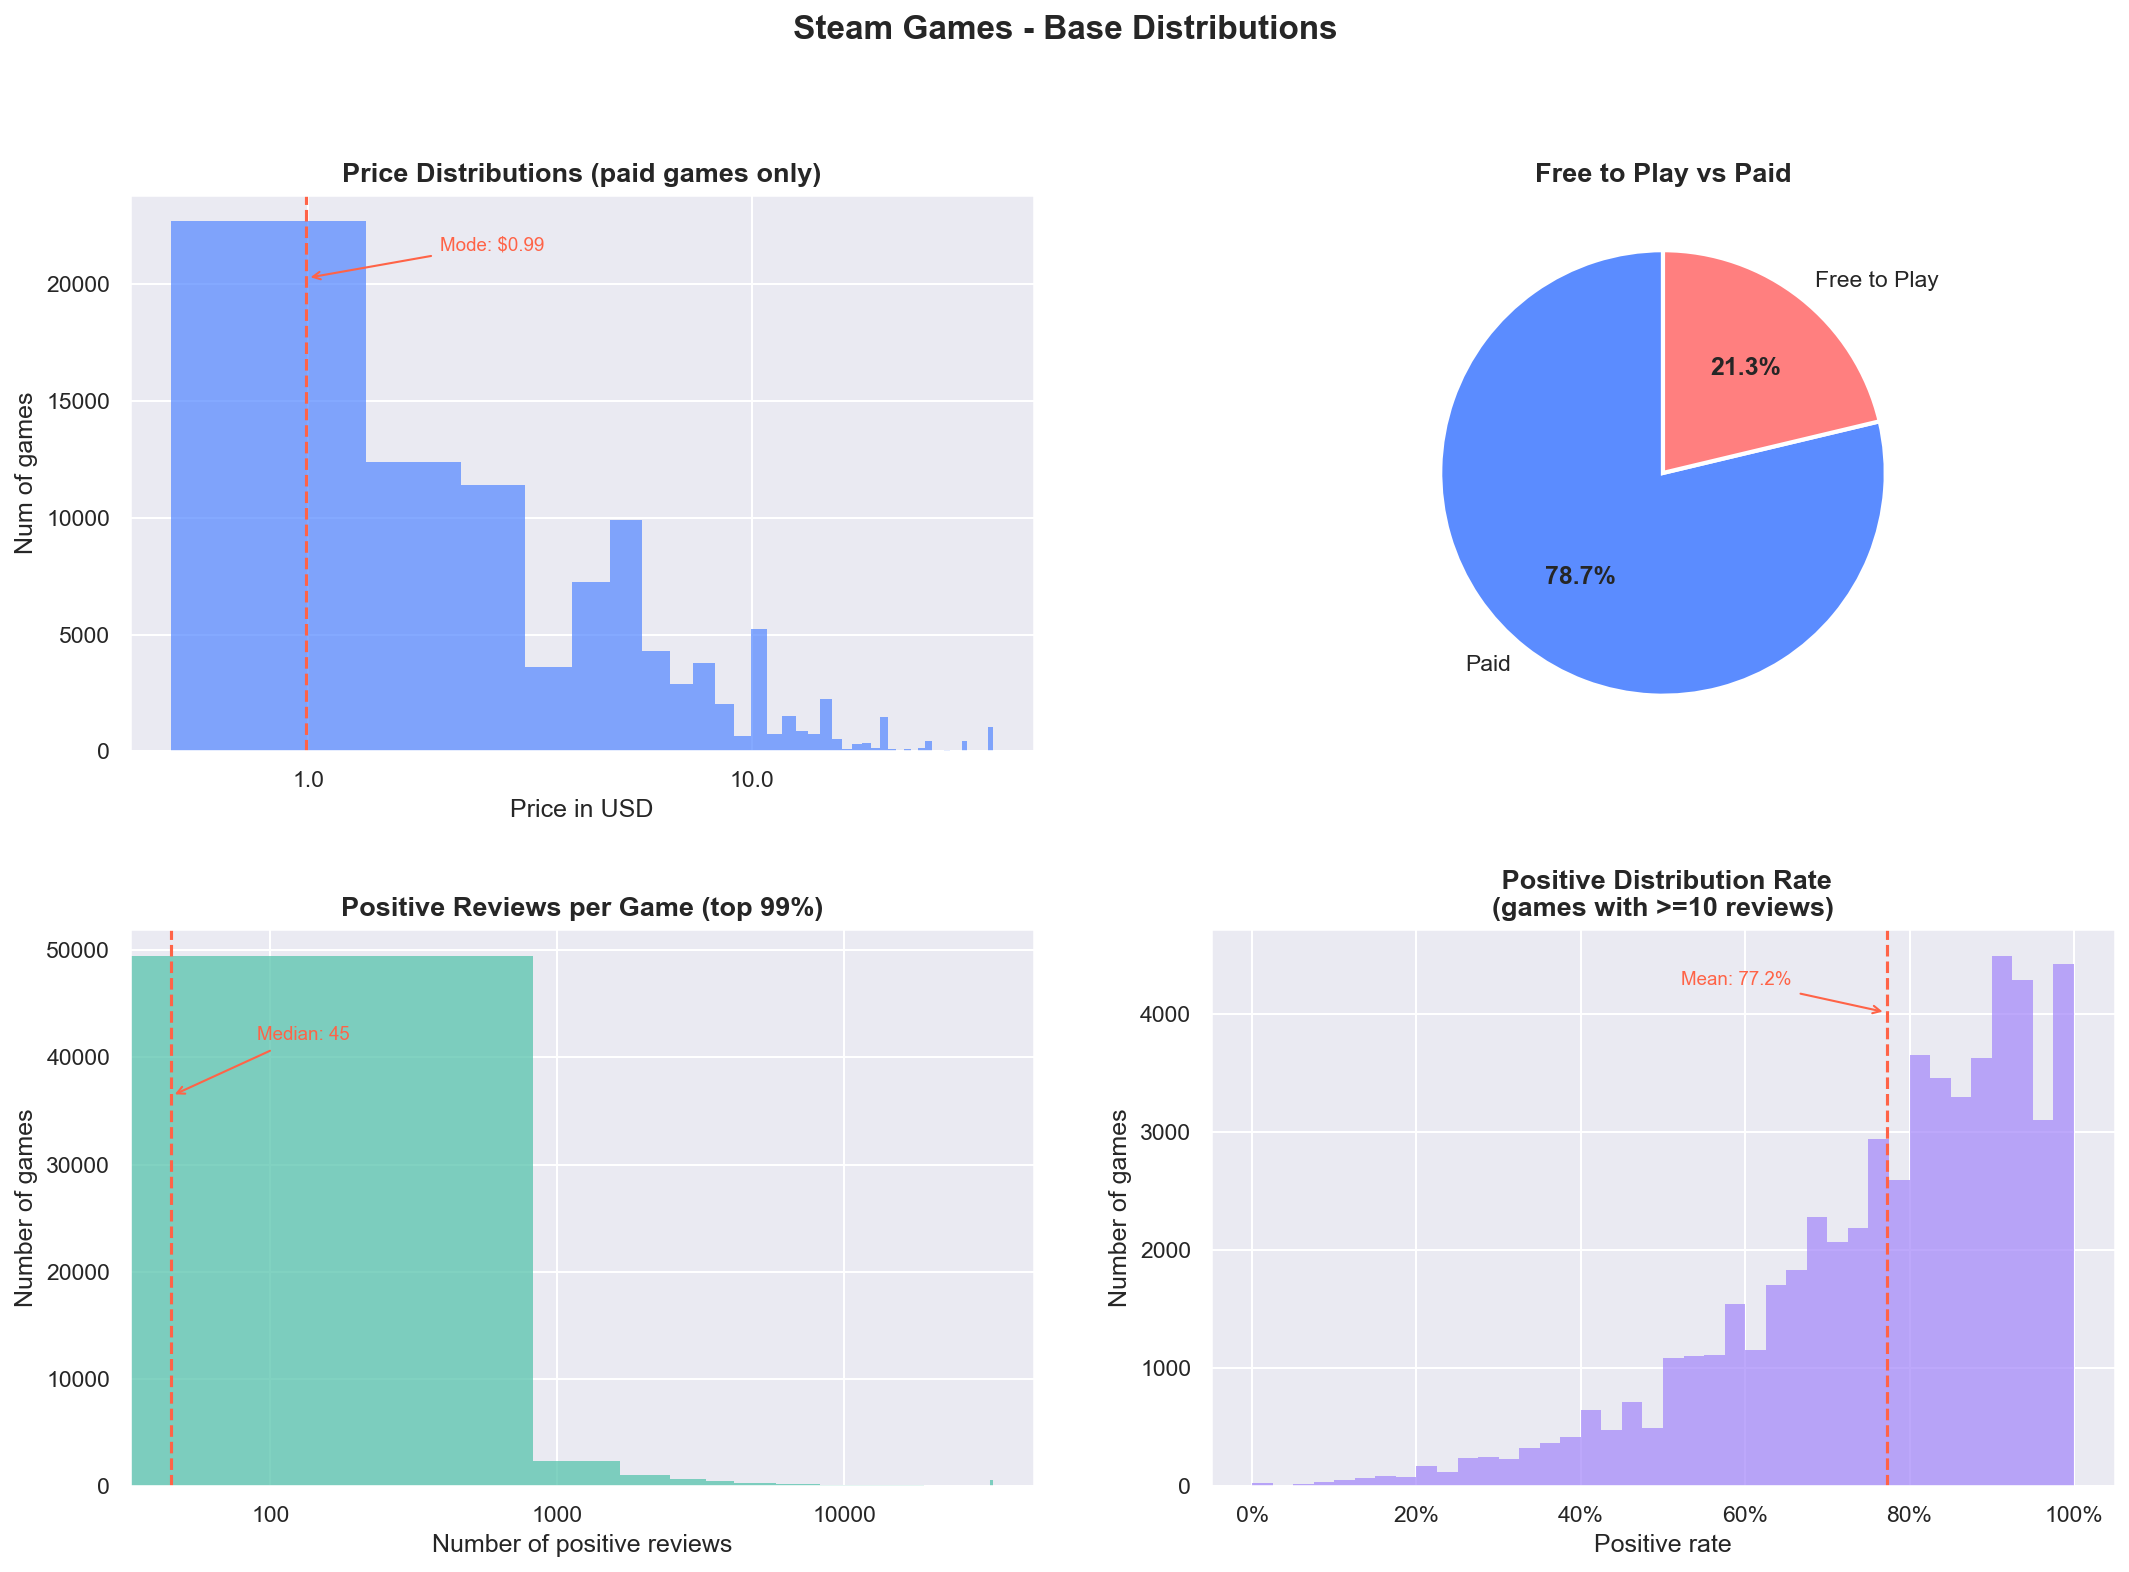

In [11]:
#Distribution base graphs

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle(
    "Steam Games - Base Distributions", fontsize=16, fontweight="bold")

# Plot 1: Price distribution (paid games only, log scale) 

ax1 = axes[0, 0]

# Only paid games
paid = games.loc[games['price'] > 0, 'price']

# Remove extreme outliers (top 1%)
paid = paid.clip(upper=paid.quantile(0.99))

# Histogram
sns.histplot(paid, bins=40, ax=ax1, color='#5B8CFF', edgecolor='none')

# Log scale
ax1.set_xscale("log")

# IMPORTANT:
# Show real values instead of log/pow
ax1.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax1.xaxis.set_minor_formatter(mticker.NullFormatter())

# Labels
ax1.set_title("Price Distributions (paid games only)")
ax1.set_xlabel("Price in USD")
ax1.set_ylabel("Num of games")

# Mode
mode_price = paid.mode()[0]

ax1.axvline(mode_price, color='tomato', linestyle='--', linewidth=1.5)

ax1.annotate(
    f"Mode: ${mode_price:.2f}",
    xy=(mode_price, ax1.get_ylim()[1] * 0.85), 
    xytext=(mode_price * 2, ax1.get_ylim()[1] * 0.9),
    arrowprops=dict(arrowstyle="->", color="tomato"),
    color="tomato",
    fontsize=9
)

# Plot 2: Free to Play vs Paid 

ax2 = axes[0, 1]

f2p_counts = pd.Series(
    np.where(games['price'] == 0, 'Free to Play', 'Paid')
).value_counts()

wedges, texts, autotexts = ax2.pie(
    f2p_counts,
    labels=f2p_counts.index,
    autopct='%1.1f%%', # format: 70 -> 70.0%
    colors=["#5B8CFF", "#FF7F7F"],
    startangle=90, # start pie at top or 12pm
    wedgeprops=dict(edgecolor='white', linewidth=2) # to each segment or slice
)

for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight("bold")

ax2.set_title("Free to Play vs Paid")

# Plot 3: Positive reviews distribution (top 99%)

ax3 = axes[1, 0]

# Filter games with at least 1 positive review 
positive_reviews = games_reviewed['positive']

# Clip to remove extreme outliers
positive_reviews = positive_reviews.clip( upper=positive_reviews.quantile(0.99))

sns.histplot(positive_reviews, bins=40, ax=ax3, color='#57C4AD', edgecolor='none')

# Log scale
ax3.set_xscale("log")

# Show nums instead of log/pow 
ax3.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax3.xaxis.set_minor_formatter(mticker.NullFormatter())

ax3.set_title("Positive Reviews per Game (top 99%)")
ax3.set_xlabel("Number of positive reviews")
ax3.set_ylabel("Number of games")

# Median
median_positive = positive_reviews.median()

ax3.axvline(median_positive, color='tomato', linestyle='--', linewidth=1.5)

ax3.annotate(
    f"Median: {int(median_positive):,}",
    xy=(median_positive, ax3.get_ylim()[1] * 0.7), # Point the arrow near the mode line
    xytext=(median_positive * 2, ax3.get_ylim()[1] * 0.8), # Position the label away from the line
    arrowprops=dict(arrowstyle="->", color="tomato"),
    color="tomato",
    fontsize=9
)

# Plot 4: Positive rate distribution 

ax4 = axes[1, 1]

# IMPORTANT:
# Filter valid values
positive_rate = games_reviewed['positive_rate'].dropna()

sns.histplot(positive_rate, bins=40, ax=ax4, color='#A78BFA', edgecolor='none')
ax4.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1)) # Percentage(%) format in X 
ax4.set_title(" Positive Distribution Rate\n(games with >=10 reviews)")
ax4.set_xlabel("Positive rate")
ax4.set_ylabel("Number of games")

# Mean
mean_rate = positive_rate.mean()

ax4.axvline(mean_rate, color='tomato', linestyle='--', linewidth=1.5)
ax4.annotate(
    f"Mean: {mean_rate:.1%}",
    xy=(mean_rate, ax4.get_ylim()[1] * 0.85),
    xytext=(mean_rate - 0.25, ax4.get_ylim()[1] * 0.9),
    arrowprops=dict(arrowstyle="->", color="tomato"),
    color="tomato",
    fontsize=9
)

# FINAL AJUSTSMENTS

plt.tight_layout(pad=3)
plt.savefig('../images/01_distributions.png', bbox_inches='tight', dpi=150)
plt.show() 

### Key Findings - Base Distributions

**Price Distribution:**  
The price distribution is heavily right-skewed, with the mode at **\$0.99**. The vast majority of paid games are priced below `$15`, while a small number of titles exceed `$30`. The log scale is necessary to reveal this structure, as linear scale would collapse most games into an indistinguishable cluster near zero.

**Free to Play vs. Paid:**  
Approximately **21% of Steam games are Free to Play**, a notable proportion given that F2P titles tend to attract significantly larger player bases. This segment deserves separate treatment in downstream analyses.

**Positive Review Volume:**  
Review counts follow an extreme power-law distribution. The median sits at only **~45 positive reviews**, confirming that the vast majority of Steam games are small, low-visibility titles. A small number of blockbuster games (CS:GO, Dota 2, GTA V) account for a disproportionate share of all reviews. Log scale is again required to make this distribution readable.

**Positive Rate:**  
Among games with at least 10 reviews, the mean positive rate is approximately **77%**, with a strong left skew — most games receive predominantly positive feedback. The distribution peaks sharply near 80–100%, suggesting that games that attract enough reviews tend to be well-received.

---
## **2. Temporal Trends**

Understanding how the Steam catalog has grown over time provides critical context for interpreting the rest of the analysis. The platform has undergone major structural changes - most notably the introduction of **Steam Greenlight** (2012) and its replacement, **Steam Direct** (2017) - which dramatically lowered the barrier to entry for indie developers.

This section examines:
- The year-over-year growth in game releases
- Seasonal patterns in release timing across months
- A granular year × month heatmap of release activity
- The cumulative growth of the Steam catalog

The analysis is restricted to **2008–2025** to exclude the sparse early years and any unreleased titles with future dates.

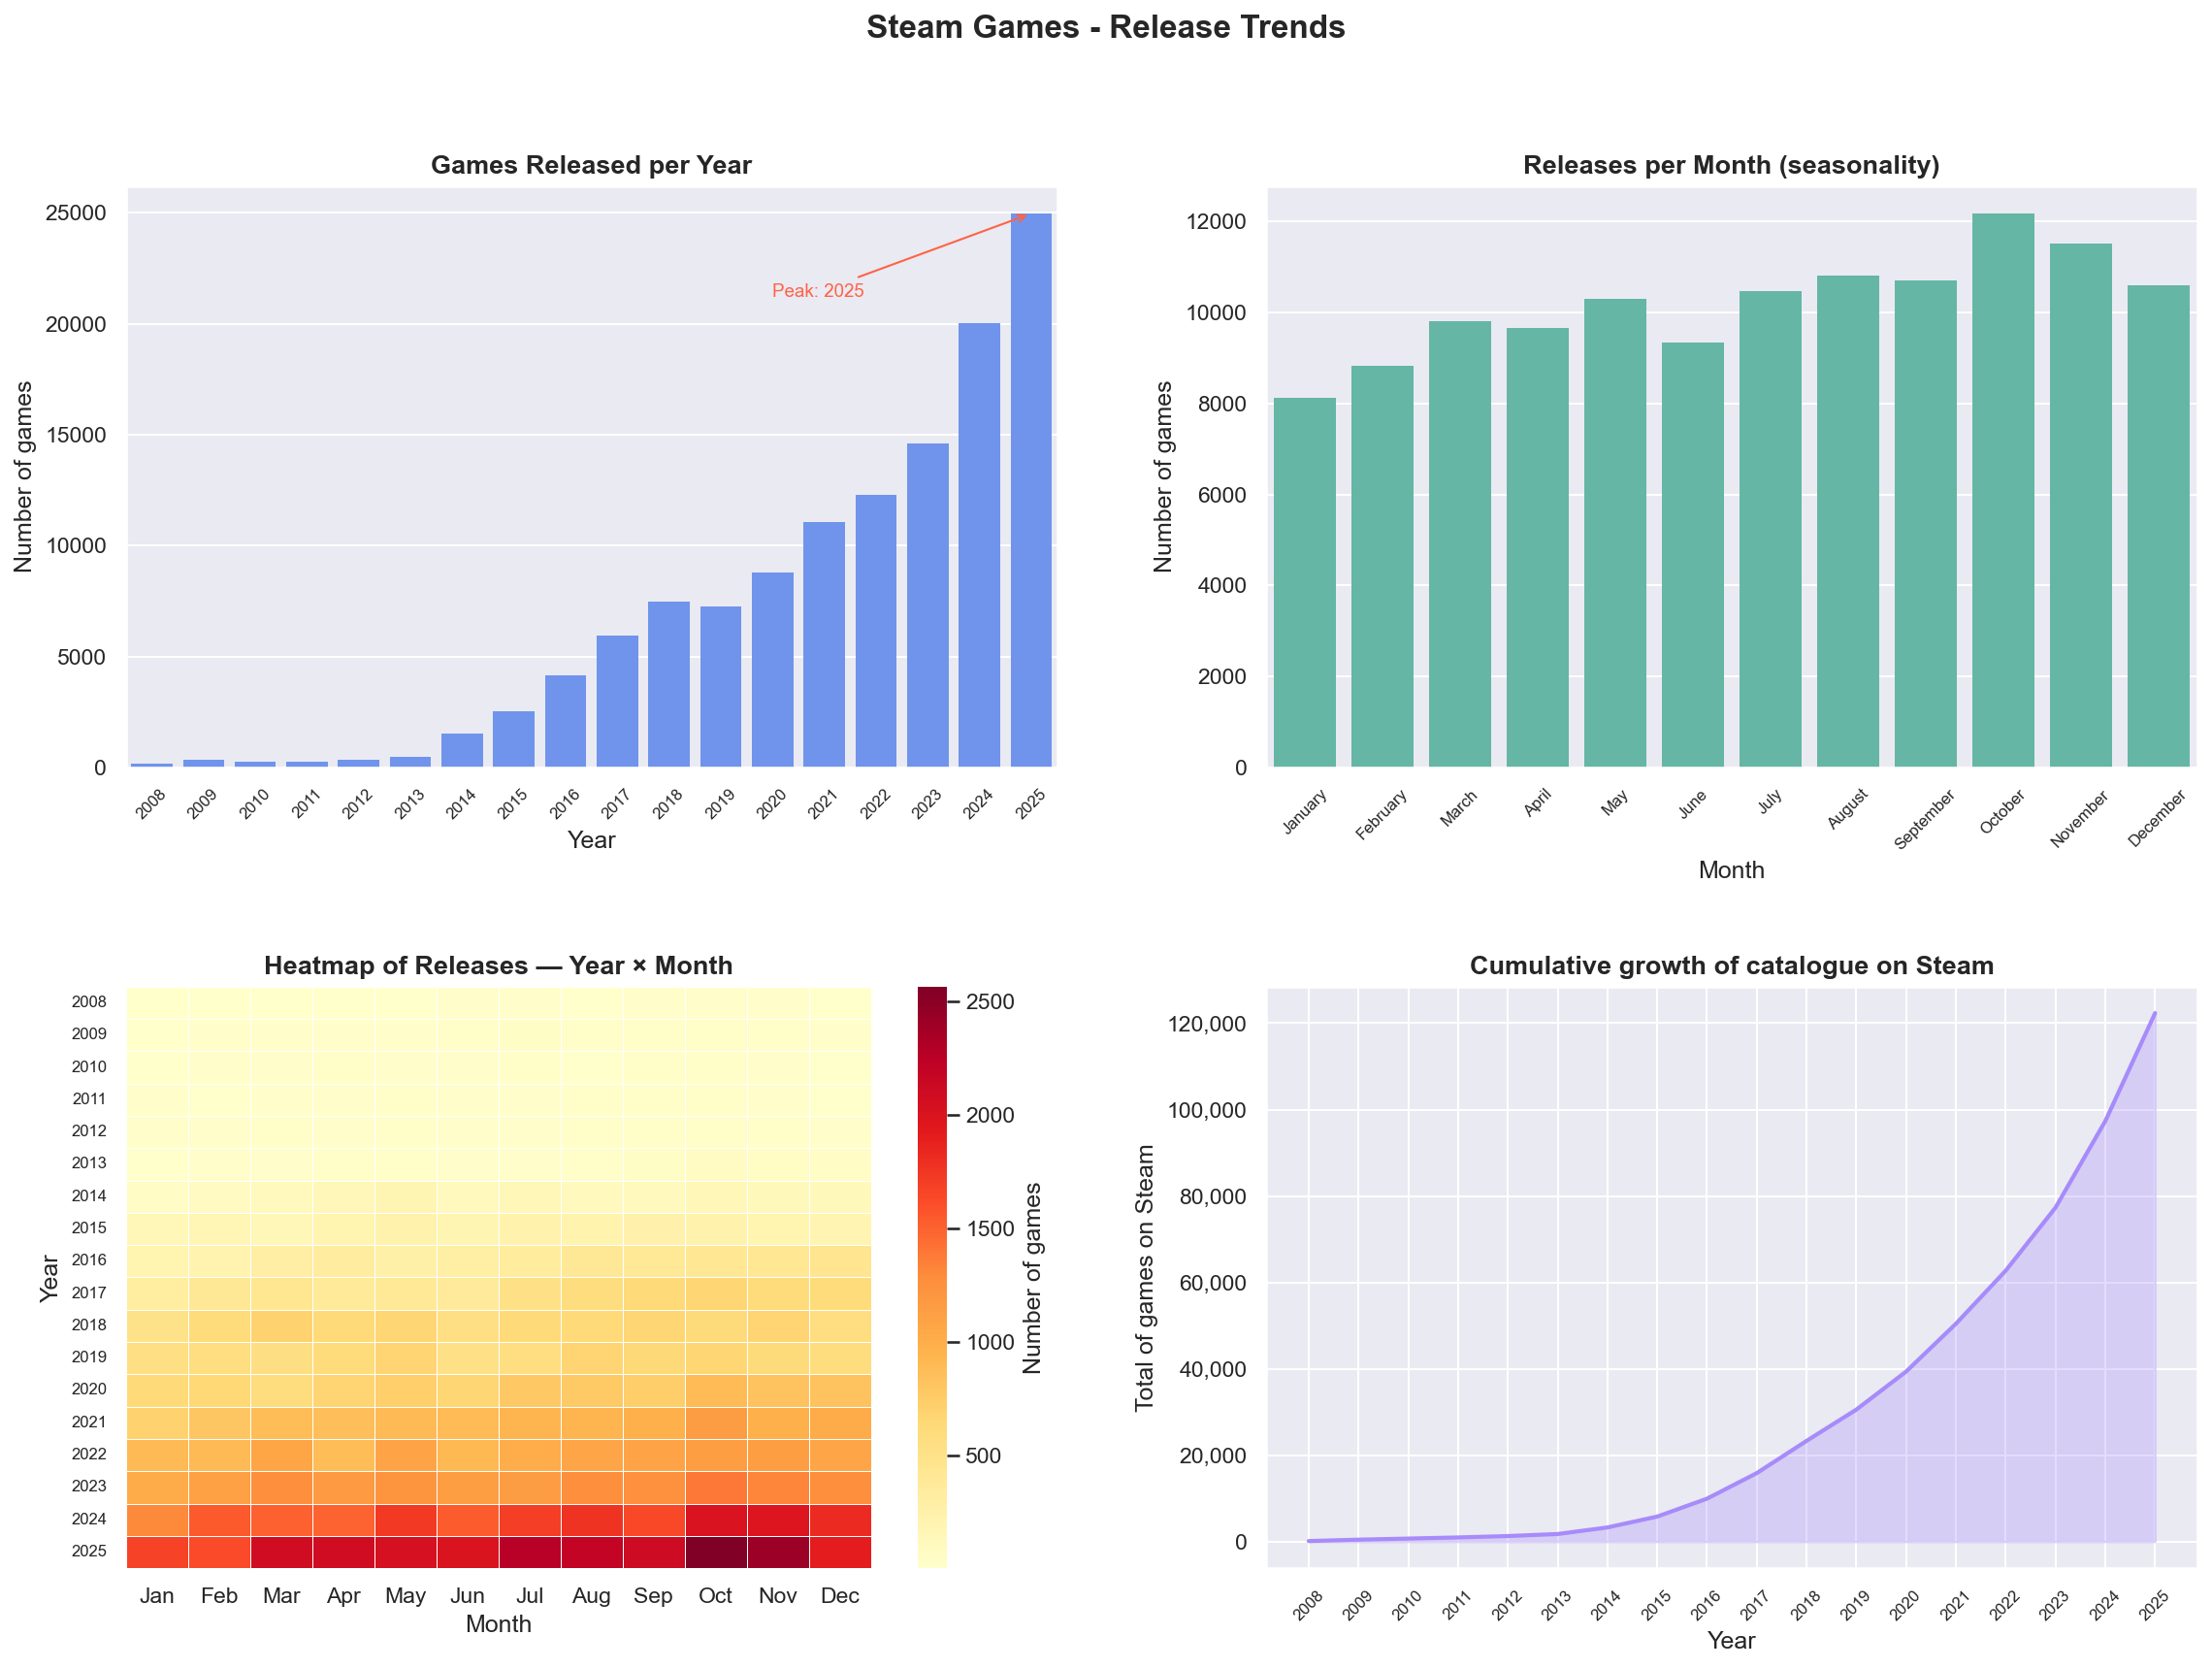

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Steam Games - Release Trends', fontsize=16, fontweight='bold')

#Filter valid years and discard nulls, future and very old years(unc years)
games_time = games[(games['release_year'] >= 2008) & (games['release_year'] <= 2025)].copy()


# Plot 1: Releases per year

ax1 = axes[0, 0]

releases_year = games_time.groupby('release_year').size().reset_index(name='count')

sns.barplot(data=releases_year, x='release_year', y='count',
            ax=ax1, color='#5B8CFF', edgecolor='none')
ax1.set_title("Games Released per Year")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of games")

# Rotate X axis labels for better readability
ax1.tick_params(axis='x', rotation=45, labelsize=8)

# Max peak
peak_year = releases_year.loc[releases_year['count'].idxmax()]
peak_x = releases_year.index[releases_year['release_year'] == peak_year['release_year']][0]
ax1.annotate(f"Peak: {int(peak_year['release_year'])}",
             xy=(peak_x, peak_year['count']),
             xytext=(peak_x - 5, peak_year['count'] * 0.85),
             arrowprops=dict(arrowstyle='->', color='tomato'),
             color='tomato', fontsize=9)

# Plot 2: Releases per month (seasonality)

ax2 = axes[0, 1]

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

releases_month = (
    games_time.groupby('release_month_name')
    .size()
    .reindex(month_order)
    .reset_index(name='count')
)

sns.barplot(data=releases_month, x='release_month_name', y='count',
            ax=ax2, color='#57C4AD', edgecolor='none')

ax2.set_title("Releases per Month (seasonality)")
ax2.set_xlabel("Month")
ax2.set_ylabel("Number of games")
ax2.tick_params(axis='x', rotation=45, labelsize=8)


# Plot 3: Heatmap year x month

ax3 = axes[1, 0]

# Pivot: rows = year, columns = months
heatmap_data = (
    games_time.groupby(['release_year', 'release_month'])
    .size()
    .unstack(fill_value=0)
)

# Rename columns to month names 
heatmap_data.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec']

sns.heatmap(heatmap_data, ax=ax3, cmap='YlOrRd',
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Number of games'})

ax3.set_title("Heatmap of Releases — Year × Month")
ax3.set_xlabel("Month")
ax3.set_ylabel("Year")
ax3.tick_params(axis='y', labelsize=8)

# Plot 4: Cumulative catalog growth

ax4 = axes[1, 1]
# Create a copy of the dataset and compute cumulative sum of game releases
cumulative = releases_year.copy()
cumulative['cumulative'] = cumulative['count'].cumsum()

ax4.fill_between(cumulative['release_year'], cumulative['cumulative'],
                 alpha=0.3, color='#A78BFA')
ax4.plot(cumulative['release_year'], cumulative['cumulative'],
         color='#A78BFA', linewidth=2)

ax4.set_title("Cumulative growth of catalogue on Steam")
ax4.set_xlabel("Year")
ax4.set_ylabel("Total of games on Steam")

# Format Y with delimiter of thousands
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
# Rotate X axis labels for better readability
ax4.set_xticks(cumulative['release_year'])
ax4.tick_params(axis='x', rotation=45, labelsize=8)

# FINAL AJUSTSMENTS 

plt.tight_layout(pad=3)
plt.savefig('../images/02_temp_tendencies.png', bbox_inches='tight', dpi=150)
plt.show() 


### Key Findings - Temporal Trends

**Year-over-Year Growth:**  
Game releases grew slowly through the early `2010s` and began accelerating sharply after `2017` with the introduction of Steam Direct. The catalog has been growing at an increasingly steep rate, reflecting both the lower barrier to publishing and the global rise of indie game development.

**Seasonality:**  
Release volume is relatively consistent across months, with a modest peak in **October and November**, aligned with the pre-holiday season window. Developers appear to time releases to capture the increased consumer spending around major seasonal sales (Halloween Sale, Autumn Sale, Winter Sale). February tends to be the quietest month.

**Heatmap - Year × Month:**  
The heatmap clearly illustrates that pre-2015 Steam was a very different platform - sparse releases, concentrated in a few titles. Post-2018, virtually every month registers high release volumes, with the darkest cells appearing in recent years.

**Cumulative Growth:**  
The cumulative curve follows a near-exponential trajectory, with the total catalog growing from roughly a few thousand titles in 2008 to over **120,000 games** by 2025. This highlights the increasing challenge of discoverability for new releases.

---
## **2. Genre Analysis**

Genre is one of the most fundamental attributes of any game, influencing both its target audience and its competitive landscape. On Steam, a single game can belong to multiple genres simultaneously, requiring an **exploded long-format** transformation before analysis.

This section examines:
- Which genres have the highest number of games (supply)
- Which genres achieve the best median positive review rate (quality signal)
- The full distribution of positive rates within each genre (variance and consistency)

Only games with **at least 10 reviews** are included to ensure statistical reliability.

In [6]:
# Data preparation: explode genres
# Each game may have multiple genres stored as a single string separated by ', '
# dropna is used to remove games with missing genre information
games_genres = games_reviewed.dropna(subset=['genres']).copy()

# Convert genres from a single string into a list
# Example: "Action, RPG" -> ["Action", "RPG"]
games_genres['genre'] = games_genres['genres'].str.split(', ')

# Explode the list so each genre becomes an individual row
# This transforms the dataset into long format 
games_exploded = games_genres.explode('genre')

# Clean whitespace from genre names
games_exploded['genre'] = games_exploded['genre'].str.strip()

# Remove any empty values that may exist after transformation
games_exploded = games_exploded[games_exploded['genre'] != '']

# Summary statistics
print(f"Unique genres: {games_exploded['genre'].nunique()}")

print("\nTop 15 genres by volume:")
print(games_exploded['genre'].value_counts().head(15))

Unique genres: 28

Top 15 genres by volume:
genre
Indie                    40581
Adventure                23959
Action                   23895
Casual                   21803
Simulation               12657
Strategy                 11612
RPG                      10950
Early Access              4672
Free To Play              4231
Sports                    2540
Racing                    2053
Massively Multiplayer     1403
Utilities                  526
Design & Illustration      336
Violent                    282
Name: count, dtype: int64


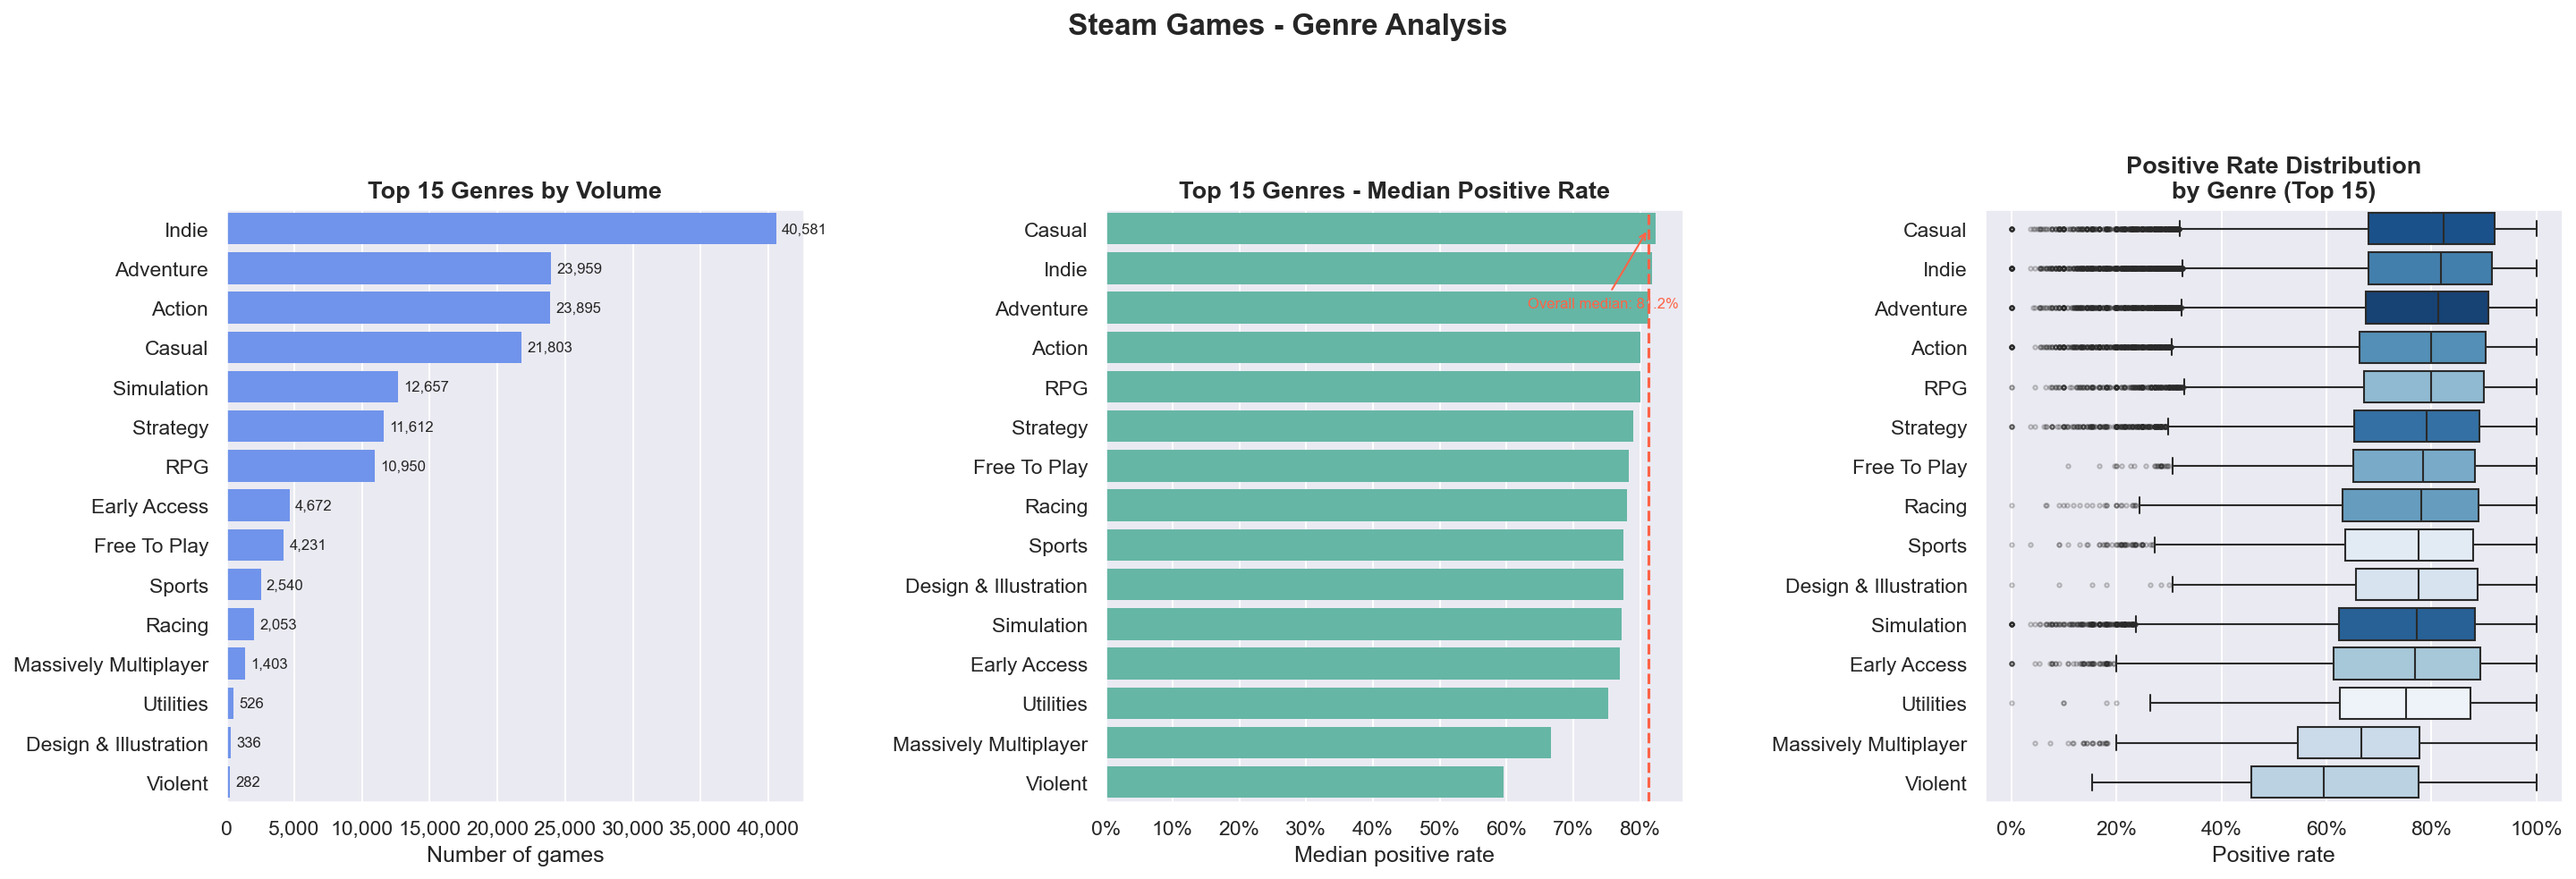

In [7]:
# Create figure
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Steam Games - Genre Analysis', fontsize=16, fontweight='bold')

# Parameters
TOP_N = 15
palette_main = '#5B8CFF'
palette_secondary = '#57C4AD'

# Top genres
top_genres = (games_exploded['genre'].value_counts().head(TOP_N).index)


# Plot 1: Top genres by volume 
ax1 = axes[0]

# Count games per genre and select the top N genres
genre_counts = games_exploded['genre'].value_counts().head(TOP_N).reset_index()
# Rename columns for clarity
genre_counts.columns = ['genre', 'count']

# Barplot for number of games per genre
sns.barplot(data=genre_counts, y='genre', x='count',
            ax=ax1, color='#5B8CFF', edgecolor='none')
ax1.set_title(f'Top {TOP_N} Genres by Volume')
ax1.set_xlabel('Number of games')
ax1.set_ylabel('')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}')) # Format x-axis with thousand separators

# Value labels to each bar
ax1.bar_label(
    ax1.containers[0],
    fmt='{:,.0f}',
    padding=3,
    fontsize=8
)

# Plot 2: Median positive rate 
ax2 = axes[1]

# Calculate the median positive rate for the top genres
genre_rating = (
    games_exploded[games_exploded['genre'].isin(top_genres)]
    .groupby('genre')['positive_rate']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)
# Barplot showing median review scores by genre
sns.barplot(data=genre_rating, y='genre', x='positive_rate',
            ax=ax2, color='#57C4AD', edgecolor='none')
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1)) # Format x-axis as percentage
ax2.set_title(f'Top {TOP_N} Genres - Median Positive Rate')
ax2.set_xlabel('Median positive rate')
ax2.set_ylabel('')

# Calculate the overall median positive rate across all games
overall_median = games_reviewed['positive_rate'].median()

# Add reference line to compare genre performance vs global median
ax2.axvline(overall_median, color='tomato', linestyle='--', linewidth=1.5)

ax2.annotate(
    f'Overall median: {overall_median:.1%}',
    xy=(overall_median, 0),
    xytext=(overall_median - 0.18, 2),
    arrowprops=dict(arrowstyle='->', color='tomato'),
    color='tomato',
    fontsize=8
)

# Plot 3: Distribution Of Positive Rate (boxplot)
ax3 = axes[2]

# Rank genres by median positive rate
# This ensures the boxplot is ordered from highest to lowest performance
genre_order = (
    games_exploded[games_exploded['genre'].isin(top_genres)]
    .groupby('genre')['positive_rate']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
# Boxplot showing distribution of positive rates by genre
# flierprops controls the appearance of outliers
sns.boxplot(
    data=games_exploded[games_exploded['genre'].isin(top_genres)],
    y='genre', x='positive_rate', hue = 'genre',
    order=genre_order,
    ax=ax3,
    palette='Blues_r',
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
# Format x-axis as percentage
ax3.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax3.set_title(f'Positive Rate Distribution\nby Genre (Top {TOP_N})')
ax3.set_xlabel('Positive rate')
ax3.set_ylabel('')

# Final layout 
plt.tight_layout(pad=3)
plt.savefig('../images/03_genres.png', bbox_inches='tight', dpi=150)
plt.show()

### Key Findings - Genre Analysis

**Genre Volume:**  
**Indie** dominates the Steam catalog by a wide margin (~40,000 games), followed by **Adventure** and **Action**. This reflects the democratization of game development — the majority of Steam releases are small, independently developed titles. Genres like **Massively Multiplayer**, **Utilities**, and **Design & Illustration** are niche categories with significantly fewer entries.

**Median Positive Rate by Genre:**  
Despite its volume dominance, **Indie** maintains a positive rate close to the overall median (~81%), suggesting neither exceptional quality nor poor reception as a category. Interestingly, **Casual** games achieve the highest median positive rate, likely due to lower user expectations and a self-selecting audience. **Violent** games show the lowest median rating, potentially reflecting polarizing content.

**Distribution of Positive Rates (Boxplot):**  
The boxplot reveals that most genres share a similar median (~75–85%) but differ significantly in their **spread**. Genres like **Massively Multiplayer** and **Violent** show wider interquartile ranges, indicating high variance in quality. In contrast, **Adventure** and **Casual** have tighter distributions, suggesting more consistent user satisfaction within these categories. All genres exhibit outliers near 0%, representing titles that received almost exclusively negative reviews.

---
## **4. Correlations With Success**

This section investigates the linear relationships between key numerical features and game success metrics. The goal is to identify which variables are most predictive of positive user reception and wide ownership.

Three complementary perspectives are examined:
- **Pairwise correlations** across all key numeric features
- **Price range vs. positive rate** -> does a higher price signal better quality?
- **Average playtime vs. positive rate** -> does engagement drive satisfaction?

The positive rate (proportion of positive reviews) and estimated ownership are used as the primary success proxies throughout this section.

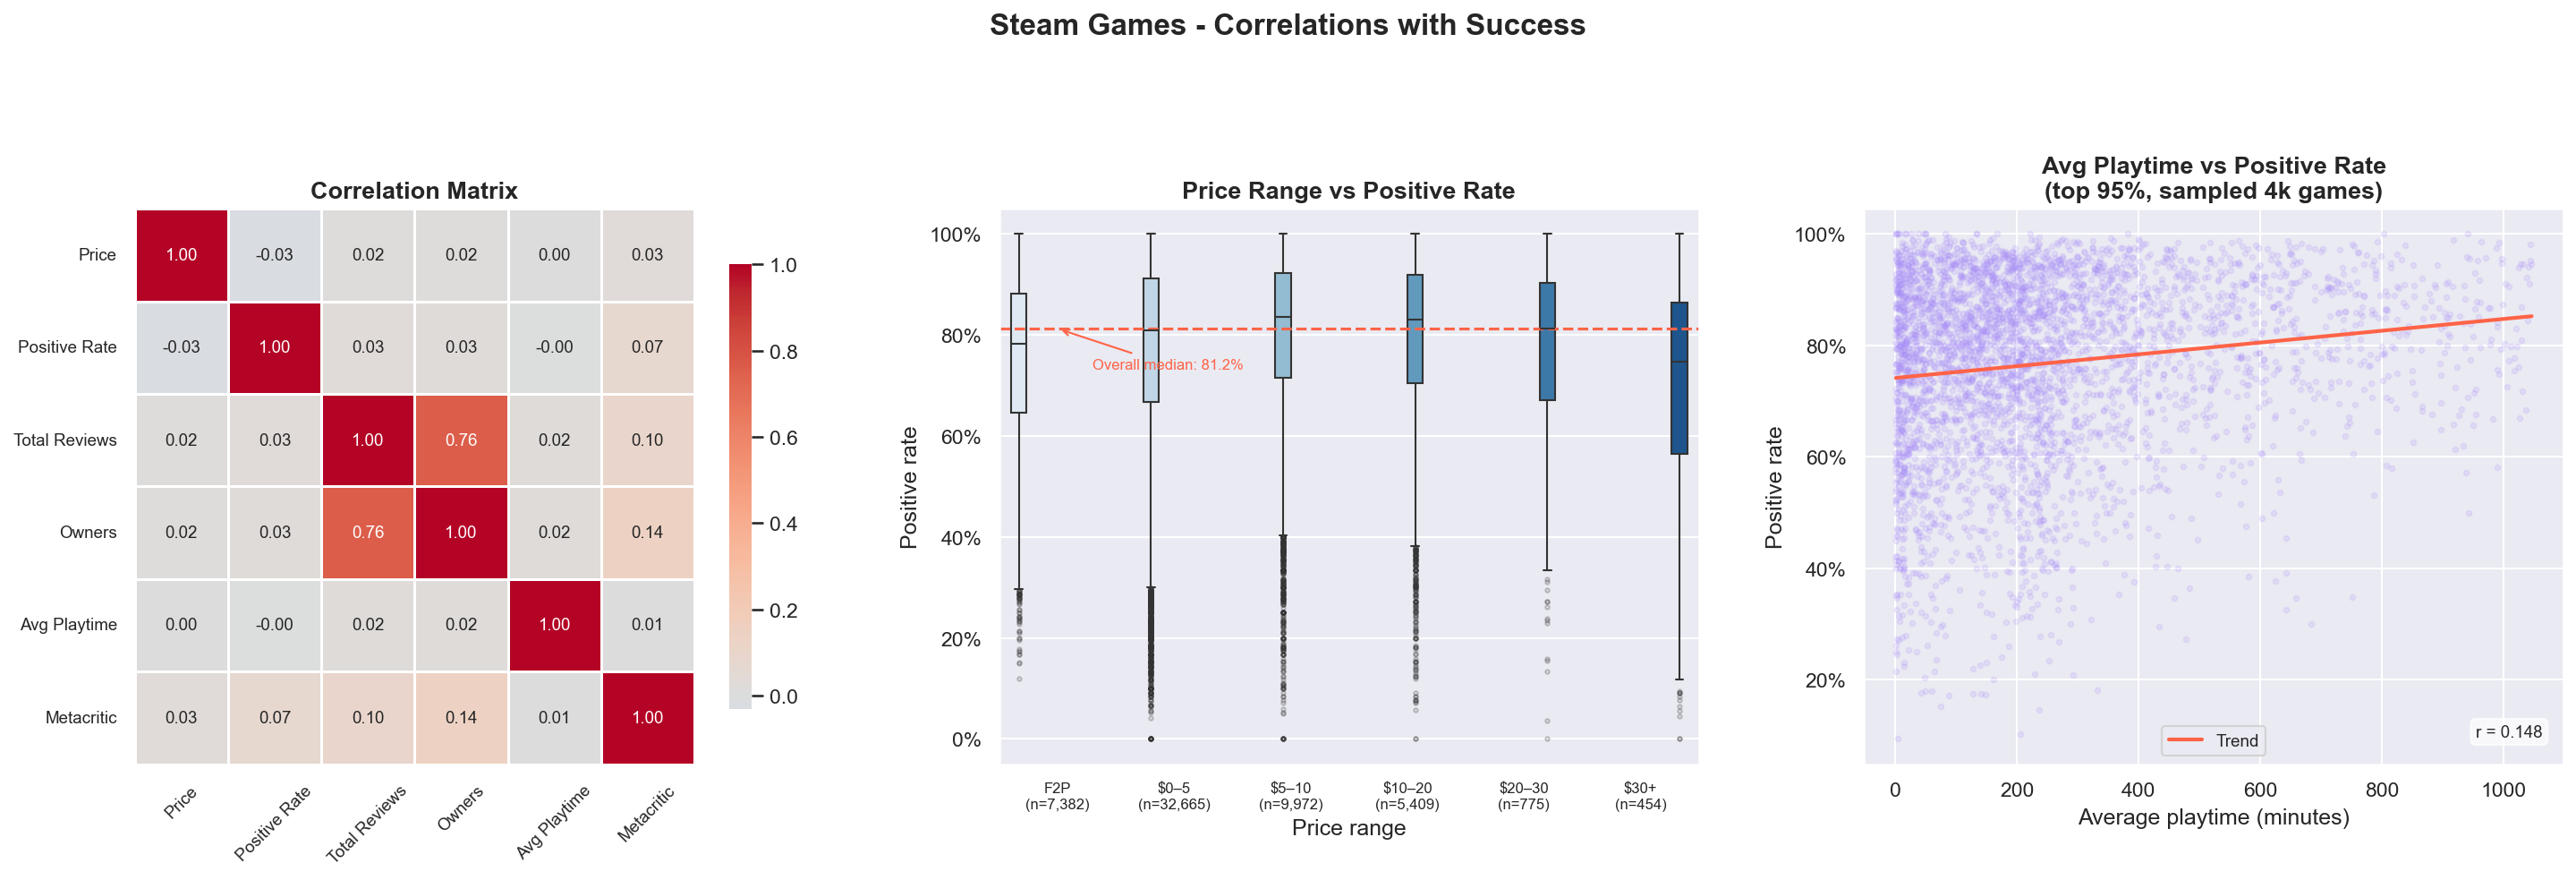

In [8]:
# This section explores relationships between key variables and game success

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Steam Games - Correlations with Success', fontsize=16, fontweight='bold')

# Plot 1: Correlation heatmap 
# Shows pairwise linear relationships between numeric variables.
# Values range from -1 (strong negative) to +1 (strong positive correlation).
ax1 = axes[0]

corr_cols = [
    'price', 'positive_rate', 'total_reviews',
    'owners_mid', 'average_playtime_forever', 'metacritic_score'
]

# Keep only columns that actually exist in the dataframe
# (prevents errors if some features are missing)
corr_cols = [c for c in corr_cols if c in games_reviewed.columns]

# Compute correlation matrix 
corr_matrix = games_reviewed[corr_cols].corr()

# Rename columns for better readability and compact display
rename_map = {
    'price': 'Price',
    'positive_rate': 'Positive Rate',
    'total_reviews': 'Total Reviews',
    'owners_mid': 'Owners',
    'average_playtime_forever': 'Avg Playtime',
    'metacritic_score': 'Metacritic'
}
corr_matrix = corr_matrix.rename(index=rename_map, columns=rename_map)

# Draw heatmap with annotations for exact correlation values
sns.heatmap(
    corr_matrix, ax=ax1,
    annot=True, fmt='.2f',  # show values with 2 decimals
    cmap='coolwarm', center=0, # diverging colormap centered at 0
    linewidths=0.5, linecolor='white',  # grid lines for readability
    cbar_kws={'shrink': 0.8}, # slightly smaller colorbar
    annot_kws={'size': 9}
)

ax1.set_title('Correlation Matrix')
ax1.tick_params(axis='x', rotation=45, labelsize=9)  # rotate labels to avoid overlap
ax1.tick_params(axis='y', rotation=0, labelsize=9)

# Plot 2: Price bucket vs positive rate (boxplot) 
# Examines how user satisfaction (positive rate) varies across price ranges.

ax2 = axes[1]

price_bins   = [0, 0.01, 5, 10, 20, 30, 999]
price_labels = ['F2P', '$0–5', '$5–10', '$10–20', '$20–30', '$30+']

# Create a temporary copy to avoid modifying the original dataframe
temp = games_reviewed.copy()

# Discretize price into categorical buckets
temp['price_bucket'] = pd.cut(
    temp['price'], bins=price_bins, labels=price_labels, right=False
)

# Draw boxplot for each price bucket
sns.boxplot(
    data=temp.dropna(subset=['price_bucket']), # remove rows without bucket
    x='price_bucket', y='positive_rate', hue = 'price_bucket',
    order=price_labels, # enforce logical order
    ax=ax2,
    palette='Blues',
    flierprops=dict(marker='o', markersize=2, alpha=0.3) # subtle outliers
)

# Format y-axis as percentage (since positive_rate ∈ [0,1])
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax2.set_title('Price Range vs Positive Rate')
ax2.set_xlabel('Price range')
ax2.set_ylabel('Positive rate')

# Add global median reference line for comparison
overall_median = games_reviewed['positive_rate'].median()
ax2.axhline(overall_median, color='tomato', linestyle='--', linewidth=1.5)

# Annotate the median line to highlight benchmark performance
ax2.annotate(
    f'Overall median: {overall_median:.1%}',
    xy=(0, overall_median),
    xytext=(0.3, overall_median - 0.08),
    arrowprops=dict(arrowstyle='->', color='tomato'),
    color='tomato',
    fontsize=8
)

# Add number of games per bucket to provide context (sample size awareness)
bucket_counts = temp['price_bucket'].value_counts()
new_labels = [
    f'{label}\n(n={bucket_counts.get(label, 0):,})'
    for label in price_labels
]
ax2.set_xticks(range(len(price_labels)))
ax2.set_xticklabels(new_labels, fontsize=8)

# Plot 3: Playtime vs positive rate (scatter + trend) 
# Investigates whether more engaged players (higher playtime)
# tend to leave more positive reviews.
ax3 = axes[2]

# Remove invalid values (playtime <= 0)
# and cap extreme outliers (top 5%) to improve visualization clarity
pt_cap = games_reviewed['average_playtime_forever'].quantile(0.95)

sample = games_reviewed[
    (games_reviewed['average_playtime_forever'] > 0) &
    (games_reviewed['average_playtime_forever'] <= pt_cap)
].sample(
    min(4000, len(games_reviewed)),  # sample for performance & readability
    random_state=42 # reproducibility
)

# Scatter plot with transparency to reduce overplotting
ax3.scatter(
    sample['average_playtime_forever'],
    sample['positive_rate'],
    alpha=0.15,
    s=8,
    color='#A78BFA'
)

# Fit a simple linear regression (degree 1 polynomial)
# to capture the general trend between variables
z = np.polyfit(sample['average_playtime_forever'], sample['positive_rate'], 1)
p = np.poly1d(z)

# Generate smooth x values for plotting the trend line
x_line = np.linspace(
    sample['average_playtime_forever'].min(),
    sample['average_playtime_forever'].max(),
    100
)

# Plot trend line
ax3.plot(
    x_line,
    p(x_line),
    color='tomato',
    linewidth=2,
    label='Trend'
)

# Format y-axis as percentage
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax3.set_title('Avg Playtime vs Positive Rate\n(top 95%, sampled 4k games)')
ax3.set_xlabel('Average playtime (minutes)')
ax3.set_ylabel('Positive rate')
ax3.legend(fontsize=9)

# Compute and display Pearson correlation coefficient on the plot
# Helps quantify the strength of the relationship
corr_val = sample[['average_playtime_forever', 'positive_rate']].corr().iloc[0, 1]

ax3.text(
    0.97, 0.05,
    f'r = {corr_val:.3f}',
    transform=ax3.transAxes,
    ha='right',
    fontsize=9,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)

# Adjust layout spacing to avoid overlap between subplots
plt.tight_layout(pad=3)

# Save figure for reporting or presentation
plt.savefig('../images/04_correlations.png', bbox_inches='tight', dpi=150)

# Display plots
plt.show()

### Key Findings - Correlations with Success

**Correlation Matrix:**  
The strongest correlation in the dataset is between **Total Reviews and Owners** (r = 0.76), which is expected since games with more owners naturally accumulate more reviews. Notably, **Price has near-zero correlation with Positive Rate** (r ≈ -0.03), suggesting that charging more does not translate into better user reception. **Metacritic score** shows modest positive correlation with both positive rate and ownership, confirming that critical recognition and commercial success are weakly aligned but not strongly predictive of each other.

**Price Range vs. Positive Rate:**  
All price brackets cluster around the same median positive rate (~80%), indicating that **price alone is not a determinant of user satisfaction**. However, **Free to Play** games show the widest interquartile range and the most negative outliers, reflecting the high variance typical of F2P titles since some become massively popular while many fail to retain players. Mid-range games (`$5`–`$20`) exhibit slightly more consistent ratings, possibly because a price point filters out less serious players.

**Playtime vs. Positive Rate:**  
There is a weak but statistically meaningful positive relationship (r = 0.148) between average playtime and positive review rate. Games that players invest more time in tend to receive better reviews. It's consistent with the intuition that **engagement and satisfaction are correlated**. The scatter plot shows high variance at low playtime values, where both very good and very bad games coexist, while long-playtime games lean more consistently positive.

---
## **5. Platform Support Analysis**

While Steam is primarily a Windows platform, a significant subset of games also supports **macOS** and **Linux**. Multi-platform support requires additional development effort, and this section explores whether that investment correlates with broader reach or higher user satisfaction.

Three questions are addressed:
- What share of games support each operating system?
- Does supporting more platforms correlate with better positive review rates?
- Which platform combinations are associated with the highest estimated ownership?

Log scale is used for ownership analysis due to the extreme right skew in that variable.

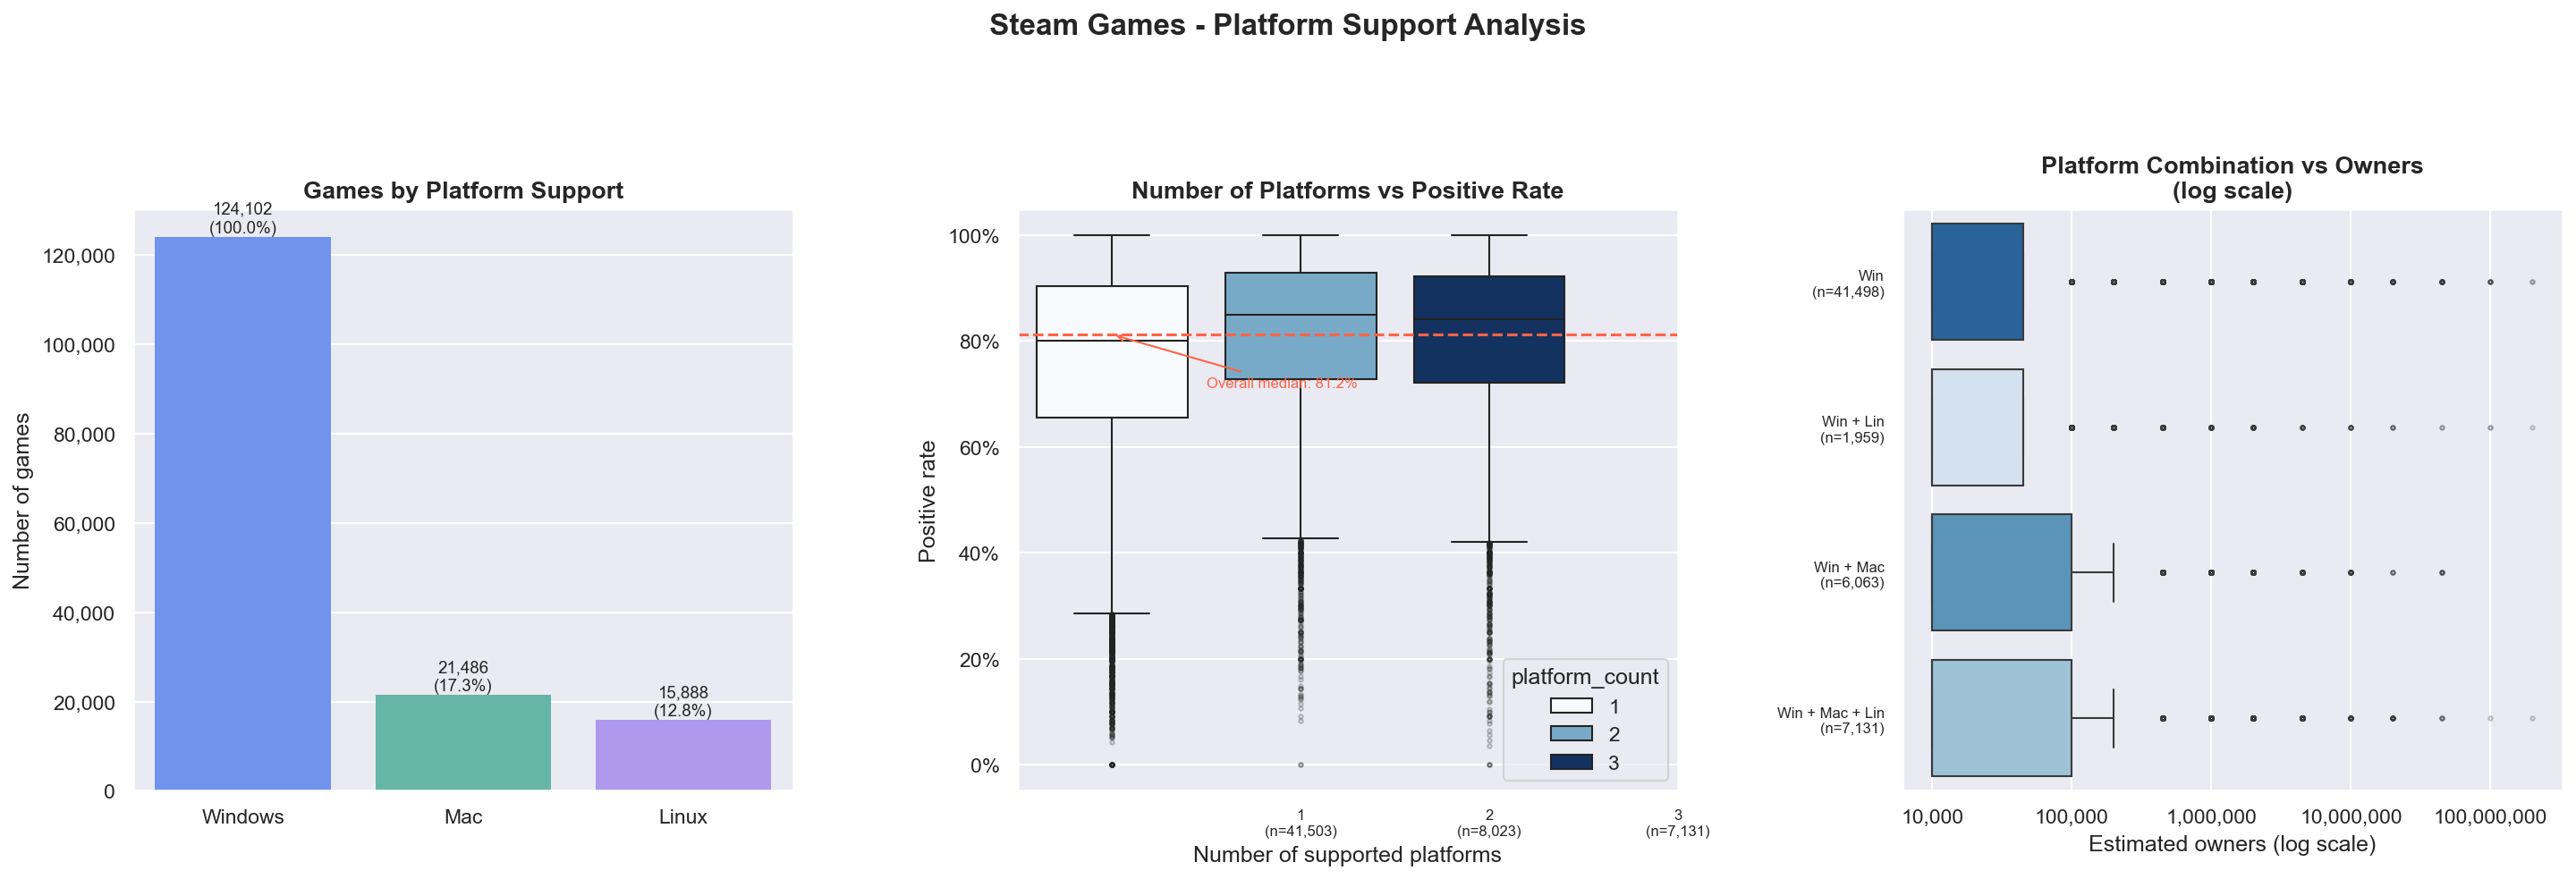

In [20]:
# This section analyzes platform support (Windows, Mac, Linux) and how it relates
# to game popularity, user satisfaction, and ownership.

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Steam Games - Platform Support Analysis', fontsize=16, fontweight='bold')

# Plot 1: Number of games per platform 
# Shows how many games support each platform (Windows, Mac, Linux)
ax1 = axes[0]

platform_counts = pd.DataFrame({
    'platform': ['Windows', 'Mac', 'Linux'],
    'count': [
        games['windows'].sum(),  # total games supporting Windows
        games['mac'].sum(), # total games supporting Mac
        games['linux'].sum() # total games supporting Linux
    ]
})

bars = sns.barplot(
    data=platform_counts,
    x='platform',
    y='count',
    hue='platform',
    ax=ax1,
    palette=['#5B8CFF', '#57C4AD', '#A78BFA'],
    edgecolor='none'
)

# Format y-axis with thousands separator for readability
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax1.set_title('Games by Platform Support')
ax1.set_xlabel('')  # no label needed for categorical axis
ax1.set_ylabel('Number of games')

# Add percentage labels on top of each bar
total_games = len(games)

for bar in ax1.patches:
    pct = bar.get_height() / total_games * 100  # percentage of total games
    ax1.text(
        bar.get_x() + bar.get_width() / 2, # center of bar
        bar.get_height() + 200, # slightly above bar
        f'{int(bar.get_height()):,}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Plot 2: Number of platforms vs positive rate 
# Analyzes whether supporting more platforms correlates with better reviews
ax2 = axes[1]

# Create a feature counting how many platforms each game supports
games_reviewed['platform_count'] = (
    games_reviewed['windows'].astype(int) +
    games_reviewed['mac'].astype(int) +
    games_reviewed['linux'].astype(int)
)

# Boxplot shows full distribution of ratings per platform count
# (not just averages, but spread and outliers)
sns.boxplot(
    data=games_reviewed,
    x='platform_count',
    y='positive_rate',
    hue='platform_count',
    ax=ax2,
    palette='Blues',
    flierprops=dict(marker='o', markersize=2, alpha=0.3)  # subtle outliers
)

# Format y-axis as percentage
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax2.set_title('Number of Platforms vs Positive Rate')
ax2.set_xlabel('Number of supported platforms')
ax2.set_ylabel('Positive rate')

# Add sample size per group (important for interpretation)
platform_counts_rev = games_reviewed['platform_count'].value_counts().sort_index()

ticks = sorted(games_reviewed['platform_count'].unique())

ax2.set_xticks(ticks)

ax2.set_xticklabels([
    f'{i}\n(n={platform_counts_rev.get(i, 0):,})'
    for i in ticks
], fontsize=8)

# Add global median reference line for comparison
ax2.axhline(overall_median, color='tomato', linestyle='--', linewidth=1.5)

# Annotate median for clarity
ax2.annotate(
    f'Overall median: {overall_median:.1%}',
    xy=(0, overall_median),
    xytext=(0.5, overall_median - 0.1),
    arrowprops=dict(arrowstyle='->', color='tomato'),
    color='tomato',
    fontsize=8
)

# Plot 3: Platform combinations vs owners
# Investigates whether certain platform combinations are associated
# with higher estimated ownership (popularity proxy)
ax3 = axes[2]

# Create a human-readable label for platform combinations
def platform_label(row):
    platforms = []
    if row['windows']: platforms.append('Win')
    if row['mac']: platforms.append('Mac')
    if row['linux']: platforms.append('Lin')
    return ' + '.join(platforms) if platforms else 'None'

games_reviewed['platform_combo'] = games_reviewed.apply(platform_label, axis=1)

# Select most common platform combinations for stable visualization
top_combos = (games_reviewed['platform_combo'].value_counts()[lambda x: x >= 50].head(6).index.tolist())

combo_data = games_reviewed[games_reviewed['platform_combo'].isin(top_combos)]

# Order combinations by median ownership (most popular first)
combo_order = (
    combo_data.groupby('platform_combo')['owners_mid']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Boxplot shows distribution of ownership per platform combination
sns.boxplot(
    data=combo_data,
    y='platform_combo',
    x='owners_mid',
    hue='platform_combo',
    order=combo_order,
    ax=ax3,
    palette='Blues_r',
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)

# Use logarithmic scale because ownership is highly skewed
ax3.set_xscale('log')

# Format ticks as readable numbers (instead of scientific notation)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax3.set_title('Platform Combination vs Owners\n(log scale)')
ax3.set_xlabel('Estimated owners (log scale)')
ax3.set_ylabel('')

# Add sample size per platform combination for context
combo_counts = games_reviewed['platform_combo'].value_counts()

ax3.set_yticks(range(len(combo_order)))
ax3.set_yticklabels([
    f'{combo}\n(n={combo_counts.get(combo, 0):,})'
    for combo in combo_order
], fontsize=8)

plt.tight_layout(pad=3)

# Save figure for reporting / portfolio use
plt.savefig('../images/05_platforms.png', bbox_inches='tight', dpi=150)

plt.show()

### Key Findings - Platform Support

**Platform Coverage:**  
**Windows support is nearly universal** (100% of games), as expected for a Windows-first platform. **Mac** support covers approximately **17%** of games, and **Linux** around **13%**. This gap reflects both the smaller market share of these operating systems and the additional porting effort required.

**Platform Count vs. Positive Rate:**  
Games supporting **all three platforms** (Windows + Mac + Linux) achieve a noticeably higher median positive rate compared to Windows-only titles. However, this is likely a **proxy effect** rather than a causal relationship since developers who invest in multi-platform support tend to be more professional studios with higher overall production quality, which independently drives better reviews.

**Platform Combinations vs. Estimated Ownership:**  
The **Win + Mac + Lin** combination is associated with the highest median estimated ownership, followed by **Win + Mac**. Windows-only games have the lowest median ownership among the represented combinations. Again, this reflects the composition of each group: cross-platform titles are disproportionately larger, more established games with pre-existing audiences. The log scale reveals that all combinations have substantial high-ownership outliers, confirming that platform support alone does not guarantee commercial success.

---
## Summary of Key Insights

| Dimension | Finding |
|---|---|
| **Pricing** | Most games are priced under \$15; price has near-zero correlation with user satisfaction |
| **F2P** | ~21% of games are Free to Play; highest variance in reception |
| **Review volume** | Extreme power-law distribution; median game has ~46 positive reviews |
| **User sentiment** | Mean positive rate of ~77%; majority of reviewed games are well-received |
| **Release trends** | Catalog growth accelerated post-2017 (Steam Direct); October/November peak seasonality |
| **Genres** | Indie dominates by volume; Casual achieves highest median positive rate |
| **Playtime** | Weak but positive correlation with satisfaction (r = 0.148) |
| **Platforms** | Multi-platform games trend higher in both ratings and ownership — likely a quality proxy |

---
*Next step: Feature engineering.*

In [22]:
print(games_reviewed.columns.tolist())
print(f"\nPrice range: {games_reviewed['price'].min()} – {games_reviewed['price'].max()}")
print(f"Playtime max: {games_reviewed['average_playtime_forever'].max()}")
print(f"Metacritic zeros: {(games_reviewed['metacritic_score'] == 0).sum()}")

['appID', 'name', 'release_date', 'peak_ccu', 'required_age', 'price', 'dlc_count', 'supported_languages', 'windows', 'mac', 'linux', 'metacritic_score', 'positive', 'negative', 'recommendations', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'developers', 'publishers', 'categories', 'genres', 'tags', 'packages', 'release_year', 'release_month', 'release_month_name', 'owners_mid', 'has_supported_languages', 'has_developers', 'has_publishers', 'has_categories', 'has_genres', 'has_tags', 'total_reviews', 'positive_rate', 'platform_count', 'platform_combo']

Price range: 0.0 – 299.99
Playtime max: 3429544
Metacritic zeros: 52512


In [26]:
# ── FEATURE ENGINEERING ───────────────────────────────────────────────────────
# All features are added to a copy to keep games_reviewed intact
import numpy as np
import pandas as pd

df = games_reviewed.copy()

# ── 1. success_score ──────────────────────────────────────────────────────────
# Composite metric that balances quality (positive_rate) with reach (review volume)
# log1p avoids penalizing games with 0 reviews and dampens the effect of outliers
# A game needs both a high positive rate AND significant review volume to score well
df['success_score'] = (
    df['positive_rate'] * np.log1p(df['total_reviews'])
)

print("Success score describe:")
print(df['success_score'].describe())
print(f"\nTop 5 by success_score:")
print(df[['name', 'positive_rate', 'total_reviews', 'success_score']]
      .sort_values('success_score', ascending=False).head())
# ── 2. price_bucket ───────────────────────────────────────────────────────────
price_bins   = [0, 0.01, 5, 10, 20, 30, 9999]
price_labels = ['F2P', '$0–5', '$5–10', '$10–20', '$20–30', '$30+']

df['price_bucket'] = pd.cut(
    df['price'],
    bins=price_bins,
    labels=price_labels,
    right=False
)

print("Price bucket distribution:")
print(df['price_bucket'].value_counts().sort_index())
# ── 3. is_free ────────────────────────────────────────────────────────────────
df['is_free'] = (df['price'] == 0).astype(int)

print(f"Free to Play games: {df['is_free'].sum():,}")
print(f"Paid games:         {(df['is_free'] == 0).sum():,}")
# ── 4. review_tier ────────────────────────────────────────────────────────────
# Segments games by review volume into meaningful tiers for dashboard filtering
# Thresholds based on the distribution observed in EDA (heavy right skew)
review_bins   = [10, 100, 1000, 10000, float('inf')]
review_labels = ['Niche', 'Mid', 'Popular', 'Blockbuster']

df['review_tier'] = pd.cut(
    df['total_reviews'],
    bins=review_bins,
    labels=review_labels,
    right=False
)

print("Review tier distribution:")
print(df['review_tier'].value_counts().sort_index())
# ── 5. release_era ────────────────────────────────────────────────────────────
# Groups release years into Steam platform eras identified in the temporal analysis
# Early Steam  : pre-2012  (before Greenlight)
# Greenlight   : 2012–2016 (community voting, opening of the platform)
# Direct Era   : 2017–2020 (Steam Direct, massive indie influx)
# Modern       : 2021+     (post-pandemic growth)
def assign_era(year):
    if year < 2012:
        return 'Early Steam'
    elif year < 2017:
        return 'Greenlight Era'
    elif year < 2021:
        return 'Direct Era'
    else:
        return 'Modern'

df['release_era'] = df['release_year'].apply(assign_era)

# Ordered categorical for correct sorting in charts
era_order = ['Early Steam', 'Greenlight Era', 'Direct Era', 'Modern']
df['release_era'] = pd.Categorical(df['release_era'], categories=era_order, ordered=True)

print("Release era distribution:")
print(df['release_era'].value_counts().sort_index())
# ── 6. is_multiplatform ───────────────────────────────────────────────────────
df['is_multiplatform'] = (df['platform_count'] > 1).astype(int)

print(f"Multiplatform games: {df['is_multiplatform'].sum():,}")
print(f"Windows-only games:  {(df['is_multiplatform'] == 0).sum():,}")
# ── 7. metacritic_tier ────────────────────────────────────────────────────────
# 52k games have score = 0, meaning no Metacritic entry — treated as its own tier
# Scores follow standard game review conventions
def metacritic_tier(score):
    if score == 0:
        return 'No Score'
    elif score < 60:
        return 'Mixed'
    elif score < 75:
        return 'Good'
    elif score < 90:
        return 'Very Good'
    else:
        return 'Outstanding'

df['metacritic_tier'] = df['metacritic_score'].apply(metacritic_tier)

tier_order = ['No Score', 'Mixed', 'Good', 'Very Good', 'Outstanding']
df['metacritic_tier'] = pd.Categorical(
    df['metacritic_tier'], categories=tier_order, ordered=True
)

print("Metacritic tier distribution:")
print(df['metacritic_tier'].value_counts().sort_index())
# ── 8. Genre one-hot flags ────────────────────────────────────────────────────
# Top 10 genres identified in EDA — each gets a binary flag column
# Useful for filtering and grouping in the dashboard without string parsing
top_genres = [
    'Indie', 'Action', 'Adventure', 'Casual', 'Simulation',
    'Strategy', 'RPG', 'Free To Play', 'Sports', 'Racing'
]

for genre in top_genres:
    col_name = f"genre_{genre.lower().replace(' ', '_')}"
    df[col_name] = df['genres'].str.contains(genre, na=False).astype(int)

print("Genre flags created:")
genre_flag_cols = [c for c in df.columns if c.startswith('genre_')]
print(df[genre_flag_cols].sum().sort_values(ascending=False))
# ── 9. Cap playtime outlier ───────────────────────────────────────────────────
# Max playtime of 3.4M minutes (~6.5 years) is clearly erroneous data
# Cap at 99th percentile to preserve the distribution without distortion
playtime_cap = df['average_playtime_forever'].quantile(0.99)
df['playtime_capped'] = df['average_playtime_forever'].clip(upper=playtime_cap)

print(f"Playtime cap (99th pct): {playtime_cap:,.0f} minutes ({playtime_cap/60:.0f} hours)")
print(df['playtime_capped'].describe())
# ── 10. Final validation & save ───────────────────────────────────────────────
new_cols = [
    'success_score', 'price_bucket', 'is_free', 'review_tier',
    'release_era', 'is_multiplatform', 'metacritic_tier', 'playtime_capped'
] + genre_flag_cols

print(f"New features added: {len(new_cols)}")
print(f"Final shape: {df.shape}")
print(f"\nNulls in new features:")
print(df[new_cols].isnull().sum()[df[new_cols].isnull().sum() > 0])

# Save enriched dataset for dashboard use
df.to_csv('../data/processed/df_featured.csv', index=False)
print("\nSaved → data/processed/df_featured.csv")

Success score describe:
count    56657.000000
mean         3.618916
std          1.834661
min          0.000000
25%          2.370230
50%          3.169074
75%          4.511767
max         13.863961
Name: success_score, dtype: float64

Top 5 by success_score:
                     name  positive_rate  total_reviews  success_score
45509    Counter-Strike 2       0.866932        8815087      13.863961
10927            Terraria       0.974818        1409473      13.802176
35440         Garry's Mod       0.967957        1159707      13.516235
44134  Black Myth: Wukong       0.966631        1150098      13.489678
95880      Stardew Valley       0.984415         886195      13.481267
Price bucket distribution:
price_bucket
F2P        7382
$0–5      32665
$5–10      9972
$10–20     5409
$20–30      775
$30+        454
Name: count, dtype: int64
Free to Play games: 7,382
Paid games:         49,275
Review tier distribution:
review_tier
Niche          33856
Mid            15594
Popular         55